# 01 - Exploratory Data Analysis

**Project**: [Flu Shot Learning: Predict H1N1 and Seasonal Flu Vaccines](https://www.drivendata.org/competitions/66/flu-shot-learning/)

**Author**: Jarret Angbazo

**Date**: May 10, 2026

---

## EDA Checklist
1. Load Data and Basic Inspection
2. Explore our dataset to understand:
3. Data structure and quality
   1. check data shape, column names and types, basic descriptive statistics
4. Target variable analysis
5. Duplicate checks
6. Train vs. Test dataframe consistency
7. Missingness analysis
8. Outlier analysis
9. Cardinality check (categorical columns)
10. Redundant and near duplicate column check
11. Feature-Target relationships
12. Class imbalance quantification
13. Data type validation

## 1. Setup and Imports

In [6]:
# Standard libraries
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load Data

In [7]:
# Define paths
DATA_PATH = Path('../data/raw')

# Load training features and labels
flu_features_train = pd.read_csv(DATA_PATH / 'training_set_features.csv', index_col='respondent_id')
flu_labels_train = pd.read_csv(DATA_PATH / 'training_set_labels.csv', index_col='respondent_id')

# Load test features
flu_features_test = pd.read_csv(DATA_PATH / 'test_set_features.csv', index_col='respondent_id')

## 3. Basic Inspection

**Goal:** Confirm what we actually have in our data before we begin analysis
- Scan for anything suspicious in data such as suspiciously large maximums, minimums that are negative when they shouldn't be
- Columns where mean and max are the same (constant columns)

### 3.1 Flu Features Training Dataframe

In [ ]:
# Inspect flu features training dataframe
print(flu_features_train.shape, "\n")               # Check the shape of the training features dataframe
print(flu_features_train.dtypes, "\n")              # Check the data types of each column
flu_features_train.head()


(26707, 35) 

h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                       object
education                       object
race                            object
sex                             object
income_pove

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [ ]:
# Summary statistics for all columns
print(flu_features_train.describe(include='all').T, "\n")


                               count unique                        top   freq  \
h1n1_concern                 26615.0    NaN                        NaN    NaN   
h1n1_knowledge               26591.0    NaN                        NaN    NaN   
behavioral_antiviral_meds    26636.0    NaN                        NaN    NaN   
behavioral_avoidance         26499.0    NaN                        NaN    NaN   
behavioral_face_mask         26688.0    NaN                        NaN    NaN   
behavioral_wash_hands        26665.0    NaN                        NaN    NaN   
behavioral_large_gatherings  26620.0    NaN                        NaN    NaN   
behavioral_outside_home      26625.0    NaN                        NaN    NaN   
behavioral_touch_face        26579.0    NaN                        NaN    NaN   
doctor_recc_h1n1             24547.0    NaN                        NaN    NaN   
doctor_recc_seasonal         24547.0    NaN                        NaN    NaN   
chronic_med_condition       

In [ ]:
print(flu_features_train.index.duplicated().sum())      # Check for duplicate index values
print(flu_features_train.index.isnull().sum())          # Check for missing index values

# If duplicate respondent_id exists, list them to investigate further
if flu_features_train.index.duplicated().any():
    print('Duplicated respondent_id:')
    print(flu_features_train[flu_features_train.index.duplicated(keep=False)])
else:
    print('No duplicated respondent_id found.')

# If missing respondent_id exists, list them to investigate further
if flu_features_train.index.isnull().any():
    print('Missing respondent_id:')
    print(flu_features_train[flu_features_train.index.isnull()])
else:
    print('No missing respondent_id found.')

0
0
No duplicated respondent_id found.
No missing respondent_id found.


### 3.2 Flu Labels Training Dataframe

In [ ]:
# Inspect flu labels training dataframe
print(flu_labels_train.shape, "\n")           # Check the shape of the training labels dataframe
print(flu_labels_train.dtypes, "\n")          # Check the data types of each column
flu_labels_train.head()

(26707, 2) 

h1n1_vaccine        int64
seasonal_vaccine    int64
dtype: object 



,h1n1_vaccine,seasonal_vaccine
respondent_id,,
0,0,0
1,0,1
2,0,0
3,0,1
4,0,0


In [ ]:
# Summary statistics for all columns
print(flu_labels_train.describe(include='all').T, "\n")


                    count      mean       std  min  25%  50%  75%  max
h1n1_vaccine      26707.0  0.212454  0.409052  0.0  0.0  0.0  0.0  1.0
seasonal_vaccine  26707.0  0.465608  0.498825  0.0  0.0  0.0  1.0  1.0 



In [ ]:
print(flu_labels_train.index.duplicated().sum())      # Check for duplicate index values
print(flu_labels_train.index.isnull().sum())          # Check for missing index values

# If duplicate respondent_id exists, list them to investigate further
if flu_labels_train.index.duplicated().any():
    print('Duplicated respondent_id:')
    print(flu_labels_train[flu_labels_train.index.duplicated(keep=False)])
else:
    print('No duplicated respondent_id found.')

# If missing respondent_id exists, list them to investigate further
if flu_labels_train.index.isnull().any():
    print('Missing respondent_id:')
    print(flu_labels_train[flu_labels_train.index.isnull()])
else:
    print('No missing respondent_id found.')

0
0
No duplicated respondent_id found.
No missing respondent_id found.


### 3.3 Flu Features Testing Dataframe

In [ ]:
# Inspect flu features testing dataframe
print(flu_features_test.shape, "\n")           # Check the shape of the testing features dataframe
print(flu_features_test.dtypes, "\n")          # Check the data types of each column
flu_features_test.head()

(26708, 35) 

h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                       object
education                       object
race                            object
sex                             object
income_pove

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
26707,2.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,1.0,1.0,5.0,1.0,1.0,35 - 44 Years,College Graduate,Hispanic,Female,"> $75,000",Not Married,Rent,Employed,mlyzmhmf,"MSA, Not Principle City",1.0,0.0,atmlpfrs,hfxkjkmi
26708,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,1.0,4.0,1.0,1.0,18 - 34 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,Non-MSA,3.0,0.0,atmlpfrs,xqwwgdyp
26709,2.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,5.0,4.0,2.0,5.0,4.0,4.0,55 - 64 Years,College Graduate,White,Male,"> $75,000",Married,Own,Employed,lrircsnp,Non-MSA,1.0,0.0,nduyfdeo,pvmttkik
26710,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,4.0,2.0,2.0,4.0,4.0,2.0,65+ Years,12 Years,White,Female,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,lrircsnp,"MSA, Not Principle City",1.0,0.0,NaN,NaN
26711,3.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,2.0,4.0,4.0,4.0,2.0,35 - 44 Years,12 Years,Black,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,lzgpxyit,Non-MSA,0.0,1.0,fcxhlnwr,mxkfnird


In [ ]:
# Summary statistics for all columns
print(flu_features_test.describe(include='all').T, "\n")


                               count unique                        top   freq  \
h1n1_concern                 26623.0    NaN                        NaN    NaN   
h1n1_knowledge               26586.0    NaN                        NaN    NaN   
behavioral_antiviral_meds    26629.0    NaN                        NaN    NaN   
behavioral_avoidance         26495.0    NaN                        NaN    NaN   
behavioral_face_mask         26689.0    NaN                        NaN    NaN   
behavioral_wash_hands        26668.0    NaN                        NaN    NaN   
behavioral_large_gatherings  26636.0    NaN                        NaN    NaN   
behavioral_outside_home      26626.0    NaN                        NaN    NaN   
behavioral_touch_face        26580.0    NaN                        NaN    NaN   
doctor_recc_h1n1             24548.0    NaN                        NaN    NaN   
doctor_recc_seasonal         24548.0    NaN                        NaN    NaN   
chronic_med_condition       

In [ ]:
print(flu_features_test.index.duplicated().sum())      # Check for duplicate index values
print(flu_features_test.index.isnull().sum())          # Check for missing index values

# If duplicate respondent_id exists, list them to investigate further
if flu_features_test.index.duplicated().any():
    print('Duplicated respondent_id:')
    print(flu_features_test[flu_features_test.index.duplicated(keep=False)])
else:
    print('No duplicated respondent_id found.')

# If missing respondent_id exists, list them to investigate further
if flu_features_test.index.isnull().any():
    print('Missing respondent_id:')
    print(flu_features_test[flu_features_test.index.isnull()])
else:
    print('No missing respondent_id found.')

0
0
No duplicated respondent_id found.
No missing respondent_id found.


### 3.4 Merge Features and Labels Training Dataframe

In [10]:
# Merge training features and labels dataframes
flu_train_merged = flu_features_train.merge(flu_labels_train, on='respondent_id')
flu_train_merged.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


## 4. Target Variables Analysis

**Goal:** Understand what we are predicting
- Print value counts/percentages for each target column
- Confirm targets contain only expected values
- Calculate correlation between the two labels
- Question: Are the labels balanced or imbalanced? Are they correlated?

In [ ]:
# Check distribution of target variables
print(flu_labels_train['h1n1_vaccine'].value_counts())          # h1n1_vaccine distribution
print(flu_labels_train['seasonal_vaccine'].value_counts())      # seasonal_vaccine distribution

h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64
seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64


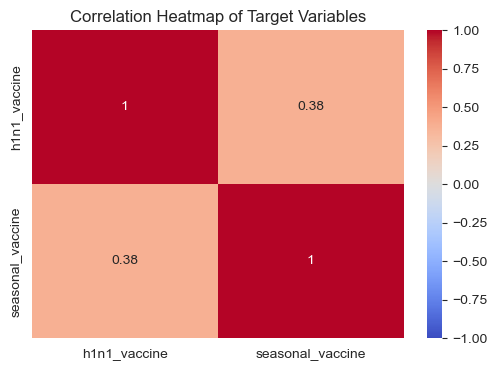

In [ ]:
# Create a correlation heatmap between the two labels
labels_corr = flu_labels_train.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(labels_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Target Variables')
plt.show()

#### Interpretation

The correlation coefficient between our target variables, `h1n1_vaccine` and `seasonal_vaccine`, is 0.38. This indicates a moderate positive correlation, suggesting that people who received one vaccine are somewhat more likely to have received the other vaccine as well. However, since the correlation is not very strong, it also suggests that there are people who received one vaccine but not the other. As a result, the two vaccines may be influenced by different factors or that there are distinct subgroups within the population with varying vaccination behaviors.


## 5. Duplicate Checks

**Goal:** Ensure that the dataset is well-formed and contains no silent data quality issues
- Check for fully duplicate rows
- Check for ID overlap between the train and test dataframes
- Note any duplicates found for cleaning

### 5.1 Merged training dataframe

#### 5.1.1 Fully Duplicate Rows

In [ ]:
print(flu_train_merged.duplicated().sum()) # Check for duplicate rows in the merged training dataframe

if flu_train_merged.duplicated().any():
    print('Duplicated rows found in the merged training data:')
    print(flu_train_merged[flu_train_merged.duplicated(keep=False)])
else:
    print('No duplicated rows found in the merged training data.')



0
No duplicated rows found.


### 5.2 Test dataframe

#### 5.2.1 Fully Duplicate Rows

In [ ]:
print(flu_features_test.duplicated().sum())             # Check for duplicate rows in the testing dataframe

if flu_features_test.duplicated().any():
    print('Duplicated rows found in the testing data:')
    print(flu_features_test[flu_features_test.duplicated(keep=False)])
else:
    print('No duplicated rows found in the testing data.')


0
No duplicated rows found in the testing data.


### 5.3 ID Overlap between train and test data

In [ ]:
# Check for id overlap between training and testing data
train_ids = set(flu_train_merged.index)
test_ids = set(flu_features_test.index)
overlap_ids = train_ids.intersection(test_ids)

print(f'Number of overlapping respondent_id between training and testing data: {len(overlap_ids)}')

if len(overlap_ids) > 0:
    print('Overlapping respondent_id:')
    print(overlap_ids)
else:
    print('No overlapping respondent_id found between training and testing data.')  

Number of overlapping respondent_id between training and testing data: 0
No overlapping respondent_id found between training and testing data.


## 6. Train vs. Test Consistency

**Goal:** Confirm that the test set has the same structure as the train set
- Confirm both sets have the same feature columns
- Confirm that for categorical columns, both sets have the same categories

### 6.1 Confirm training and test set have the same feature columns

In [ ]:
# Confirm that each dataframe has the same feature columns
train_features = set(flu_train_merged.columns) - {'h1n1_vaccine', 'seasonal_vaccine'}       # Exclude target variables
test_features = set(flu_features_test.columns)

if train_features == test_features:
    print('Training and testing data have the same feature columns.')
else:
    print('Training and testing data have different feature columns.')
    print('Training features not in testing data:', train_features - test_features)
    print('Testing features not in training data:', test_features - train_features) 

Training and testing data have the same feature columns.


### 6.2 Check categorical columns have the same categories

In [ ]:
# For each categorical column, check whether the categories in the training data are also present in the testing data
categorical_cols = flu_train_merged.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    train_categories = set(flu_train_merged[col].dropna().unique())
    test_categories = set(flu_features_test[col].dropna().unique())
    
    if not train_categories.issubset(test_categories):
        print(f'Warning: Column "{col}" has categories in training data that are not present in testing data:')
        print('Categories in training data but not in testing data:', train_categories - test_categories)
    else:
        print(f'All categories in column "{col}" from training data are present in testing data.')

All categories in column "age_group" from training data are present in testing data.
All categories in column "education" from training data are present in testing data.
All categories in column "race" from training data are present in testing data.
All categories in column "sex" from training data are present in testing data.
All categories in column "income_poverty" from training data are present in testing data.
All categories in column "marital_status" from training data are present in testing data.
All categories in column "rent_or_own" from training data are present in testing data.
All categories in column "employment_status" from training data are present in testing data.
All categories in column "hhs_geo_region" from training data are present in testing data.
All categories in column "census_msa" from training data are present in testing data.
All categories in column "employment_industry" from training data are present in testing data.
All categories in column "employment_occ

## 7. Missingness Analysis

**Goal:** Check for missing data
- Visualizations
  - Bar chart: proportion missing per column
  - Missingness correlation heatmap
  - Target rate by missingness: do rows where a feature is missing vaccinate at a different rate?
- Statistical Tests
  - Little's MCAR test on numeric columns
  - Chi-square test on categorical columns
  - Logistic regression AUC on a missingness indicator

In [ ]:
TARGET_COLS = ['h1n1_vaccine', 'seasonal_vaccine']
ID_COL = 'respondent_id'

# Columns with at least one missing value
cols_with_missing = [
    c for c in flu_train_merged.columns if flu_train_merged[c].isnull().any() and c not in TARGET_COLS + [ID_COL]
]

numeric_missing = [c for c in cols_with_missing if flu_train_merged[c].dtype in ['int64', 'float64']]
categorical_missing = [c for c in cols_with_missing if flu_train_merged[c].dtype == 'object']

print("=" * 50)
print("Missingness Summary")
print("=" * 50)
print(f"Number of columns with missing values: {len(cols_with_missing)}")
print(f"    Numeric:                           {len(numeric_missing)}")
print(f"    Categorical:                       {len(categorical_missing)}")

Missingness Summary
Number of columns with missing values: 30
    Numeric:                           23
    Categorical:                       7


### 7.1 Visual Tests

#### 7.1.1 Proportion of missing values per column

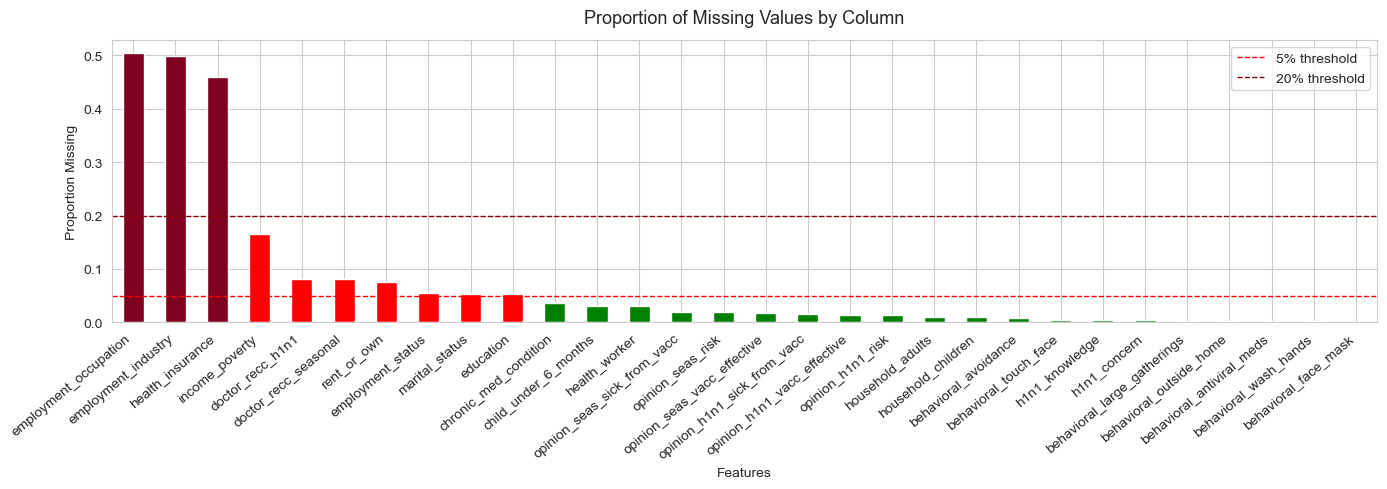

Columns with >20% missing values:
employment_occupation    0.504
employment_industry      0.499
health_insurance         0.460
dtype: float64


In [ ]:
# Missing Value Bar Chart
# Shows the proportion of missing values per column
fig, ax = plt.subplots(figsize=(14, 5))

missing_pct = (flu_train_merged[cols_with_missing].isnull().mean().sort_values(ascending=False))

colors = ['#800020' if v > 0.20 else '#FF0000' if v > 0.05 else '#008000' for v in missing_pct]
missing_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
#plt.figure(figsize=(14, 5))
#missing_pct = (flu_train_merged.isnull().sum() / len(flu_train_merged)).sort_values(ascending=False)
#missing_pct = missing_pct[missing_pct > 0]          # Filter to show only columns with missing values

#missing_pct.plot(kind = 'bar', color = '#ED7D31', edgecolor = 'white')
ax.axhline(0.05, color='red', linestyle='--', linewidth=1, label='5% threshold')
ax.axhline(0.20, color='darkred', linestyle='--', linewidth=1, label='20% threshold')
ax.set_title('Proportion of Missing Values by Column', fontsize=13, pad=12)
ax.set_ylabel('Proportion Missing')
ax.set_xlabel('Features')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/missing_01_missing_value_bar_chart.png', dpi=150)
plt.show()

print("Columns with >20% missing values:")
print(missing_pct[missing_pct > 0.20].round(3))

#### Interpretation

We see that employment_occupation, employment_industry, and health_insurance have the highest proportion of missing values, with over 20% missing. This could be due to people who are unemployed or not in the labor force not providing this information. We will investigate whether the missingness in these three features is related to employment status.

In [19]:
for col in ['employment_occupation', 'employment_industry', 'health_insurance']:
    print(f"\n--- {col} ---")
    print(pd.crosstab(
        flu_train_merged['employment_status'], 
        flu_train_merged[col].isna().map({True: 'Missing', False: 'Not Missing'}),
        margins=True
    ))


--- employment_occupation ---
employment_occupation  Missing  Not Missing    All
employment_status                                 
Employed                   323        13237  13560
Not in Labor Force       10231            0  10231
Unemployed                1453            0   1453
All                      12007        13237  25244

--- employment_industry ---
employment_industry  Missing  Not Missing    All
employment_status                               
Employed                 183        13377  13560
Not in Labor Force     10231            0  10231
Unemployed              1453            0   1453
All                    11867        13377  25244

--- health_insurance ---
health_insurance    Missing  Not Missing    All
employment_status                              
Employed               5962         7598  13560
Not in Labor Force     4370         5861  10231
Unemployed              592          861   1453
All                   10924        14320  25244


In line with our expectations, the missingness in 'employment_occupation', 'employment_industry', and 'health_insurance' is strongly correlated with 'employment_status'. This suggests that the missing values in these columns are likely not random, but rather systematically related to whether a respondent is employed or not.

#### 7.1.2 Missingness correlation heatmap

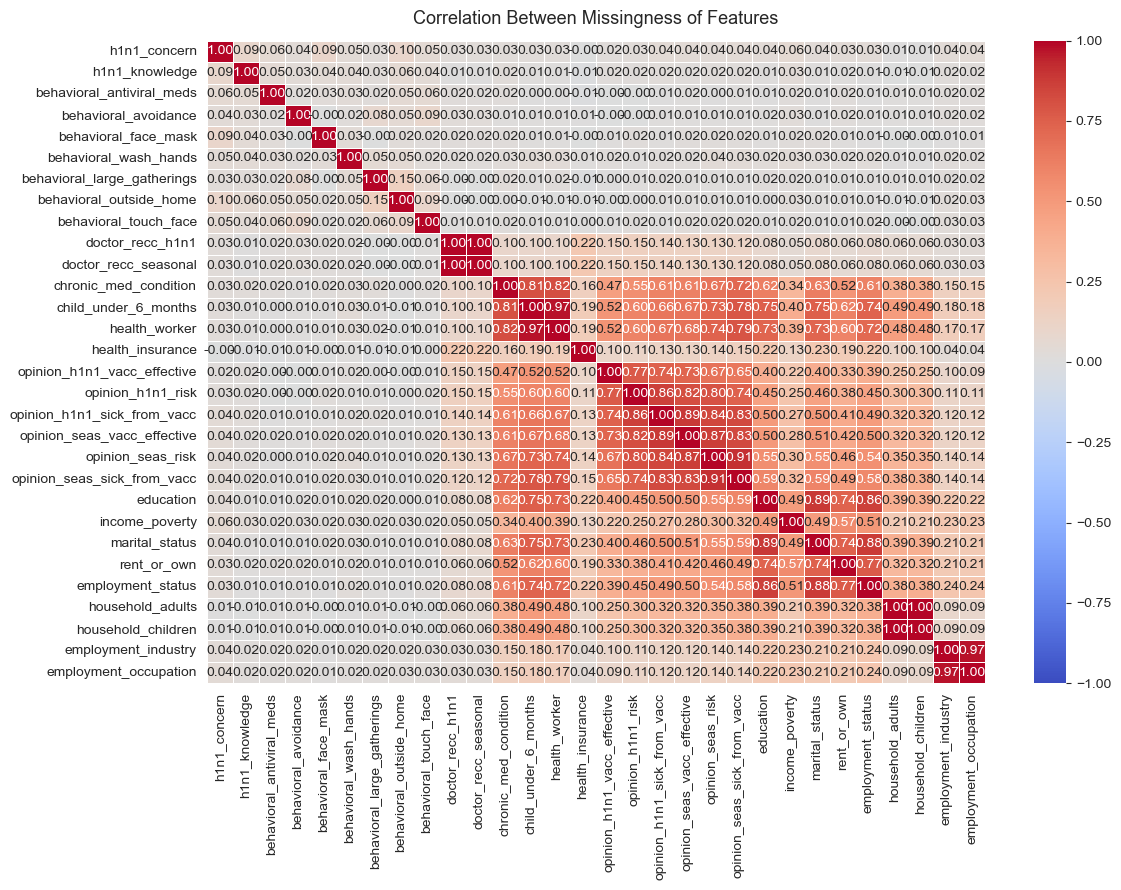

Strongest co-missingness correlations:
household_adults             household_children             1.000
doctor_recc_h1n1             doctor_recc_seasonal           1.000
employment_industry          employment_occupation          0.973
child_under_6_months         health_worker                  0.970
opinion_seas_risk            opinion_seas_sick_from_vacc    0.912
education                    marital_status                 0.888
opinion_h1n1_sick_from_vacc  opinion_seas_vacc_effective    0.885
marital_status               employment_status              0.876
opinion_seas_vacc_effective  opinion_seas_risk              0.868
education                    employment_status              0.864
dtype: float64


In [ ]:
# Missingness correlation heatmap
# Shows whether features tend to be missing together, which can indicate underlying patterns

missing_indicators = flu_train_merged[cols_with_missing].isnull().astype(int) # Create a binary indicator matrix (1 = missing, 0 = not missing)
corr_matrix = missing_indicators.corr() # Compute correlation matrix of missing indicators

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1,
            linewidth=0.5,
            ax=ax)
ax.set_title('Correlation Between Missingness of Features', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../reports/figures/missing_02_missingness_correlation_matrix.png', dpi=150)
plt.show()

# Print the strongest co-missingness pairs for reference
pairs = (corr_matrix
         .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
         .stack()
         .sort_values(ascending=False))

print("=" * 50)
print("Strongest co-missingness correlations:")
print("=" * 50)
print(pairs.head(10).round(3))


#### Interpretation

- The correlation coefficient on doctor_recc_h1n1 and doctor_recc_seasonal is 1 meaning

#### 7.1.3 Target Rate by Missingness

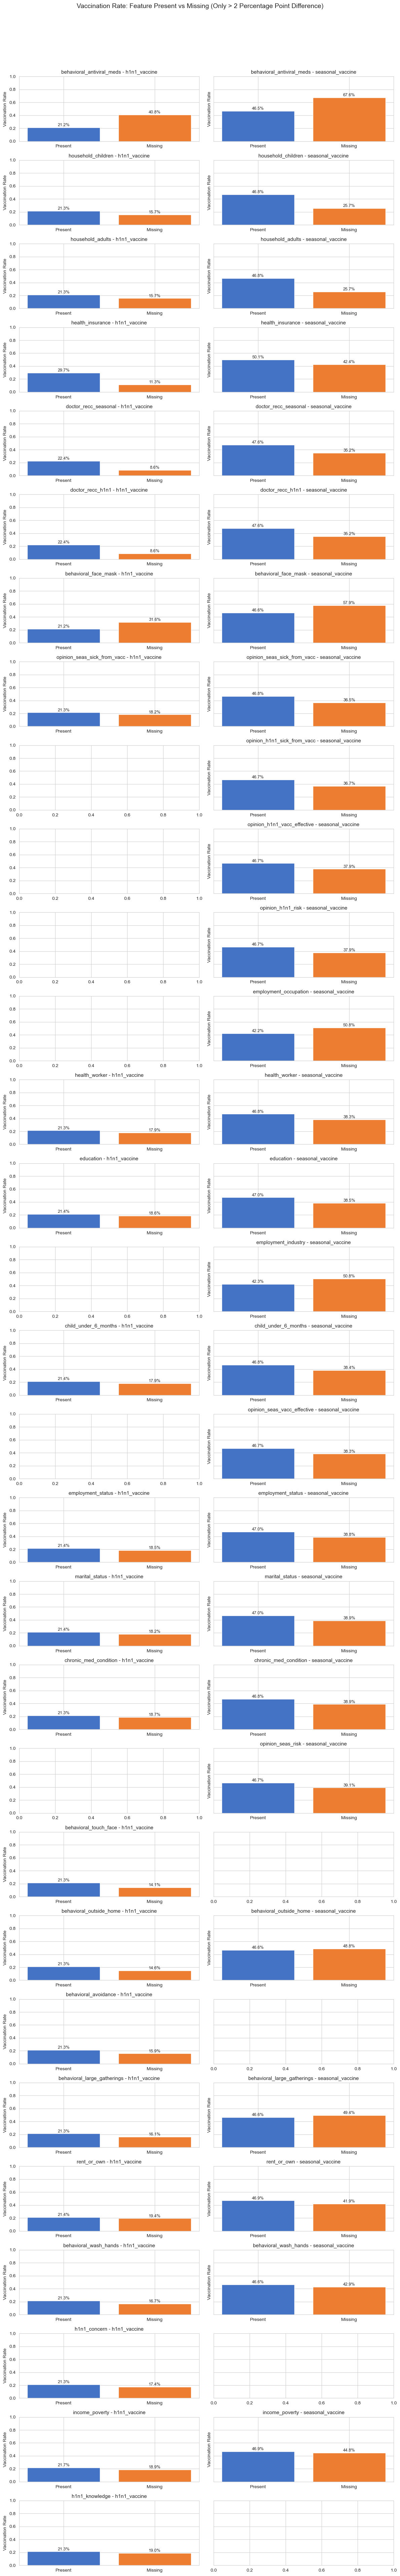

In [ ]:
# Target Rate by Missingness
# If vaccination rates differ between rows where a feature is present or missing, the missingness is related to the outcome (MNAR)

records = []
for col in cols_with_missing:
    mask = flu_train_merged[col].isnull()
    for target in TARGET_COLS:
        rate_present = flu_train_merged.loc[~mask, target].mean()       # Vaccination rate where feature is present
        rate_missing = flu_train_merged.loc[mask, target].mean()        # Vaccination rate where feature is missing
        records.append({
            'feature': col,
            'target': target,
            'rate_present': rate_present,
            'rate_missing': rate_missing,
            'difference': abs(rate_present - rate_missing)
        })

rate_df = pd.DataFrame(records)

# Bar chart comparing vaccination rates for present vs missing (only plot features with > 2 percentage point difference)
plot_df = rate_df[rate_df['difference'] > 0.02].sort_values('difference', ascending=False)

if len(plot_df) == 0:
    print("No features with > 2 percentage point difference in vaccination rates between present and missing. Weak MNAR signal.")
else:
    n_features = plot_df['feature'].nunique()
    fig, axes = plt.subplots(
        n_features, 2,
        figsize=(12, n_features * 2.5),
        sharey=True
    )
    # Handle single-row case
    if n_features == 1:
        axes = np.array([axes]) # Ensure axes is always 2D for consistent indexing

    for i, feature in enumerate(plot_df['feature'].unique()):
        subset = plot_df[plot_df['feature'] == feature]
        for j, target in enumerate(TARGET_COLS):
            ax = axes[i, j]
            row = subset[subset['target'] == target]
            if len(row) == 0:
                continue
            bars = ax.bar(
                ['Present', 'Missing'],
                [row['rate_present'].values[0],
                 row['rate_missing'].values[0]],
                 color=['#4472C4', '#ED7D31'],
                 edgecolor='white'
            )
            ax.set_title(f'{feature} - {target}', fontsize=11)
            ax.set_ylim(0, 1)
            ax.set_ylabel('Vaccination Rate')
            for bar in bars:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f'{bar.get_height():.1%}',
                    ha='center', fontsize=9
                )

plt.suptitle(
    'Vaccination Rate: Feature Present vs Missing (Only > 2 Percentage Point Difference)', fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig('../reports/figures/missing_03_vaccination_rate_by_missingness.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Statistical Tests

#### 7.2.1 Little's MCAR Test

In [ ]:
# Little's MCAR Test
# Statistical test to determine if data is Missing Completely At Random (MCAR). The only formal test specifically for MCAR. A non-significant p-value (p > 0.05) suggests that the data is consistent with MCAR, while a significant p-value (p < 0.05) indicates that the data is not MCAR (could be MAR or MNAR).
from pyampute.exploration.mcar_statistical_tests import MCARTest

if len(numeric_missing) == 0:
    print("No numeric columns with missing values found. Little's MCAR Test cannot be performed.")
    p_little = None
else:
    mcar_test = MCARTest(method = 'little')
    p_little = mcar_test.little_mcar_test(flu_train_merged[numeric_missing])
    print("=" * 50)
    print("Little's MCAR Test Results")
    print("=" * 50)
    print(f"p-value: {p_little:.4f}")
    if p_little < 0.05:
        print("Reject null hypothesis. Missingness in numeric features not at random (could be MAR or MNAR)")
    else:
        print("Do not reject null hypothesis. Missingness in numeric features maybe at random (MCAR)")
        print()

Little's MCAR Test Results
p-value: 0.0000
Reject null hypothesis. Missingness in numeric features not at random (could be MAR or MNAR)


#### 7.2.2 Chi-Quared Test for Categorical Features

In [ ]:
# Chi-Squared Test for Categorical Missingness
# Chi-square tests whether the distribution of each categorical feature differs between rows where another feature is present vs missing. A significant result (p < 0.05) suggests that the missingness of one feature is related to the distribution of another, indicating that the data is not MCAR.
from scipy.stats import chi2_contingency

chi2_results = []

for col_missing in categorical_missing:
    mask = flu_train_merged[col_missing].isnull()

    # Test against all categorical features
    for col_cat in categorical_missing:
        if col_cat == col_missing:
            continue

        contingency = pd.crosstab(
            flu_train_merged[col_cat].fillna('__missing__'),
            mask
        )
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            continue  # Skip if not enough data for chi-squared test

        chi2, p_val, dof, _ = chi2_contingency(contingency)
        chi2_results.append({
            'missing_feature': col_missing,
            'predictor_feature': col_cat,
            'chi2': round(chi2, 3),
            'p_value': round(p_val, 4),
            'significant_mar': p_val < 0.05
        })

chi2_df = pd.DataFrame(chi2_results)

# Summarize how many significant relationships per missing column
chi2_summary = (chi2_df.groupby('missing_feature')['significant_mar']
                .sum()
                .reset_index()
                .rename(columns={'significant_mar': 'n_significant_relationships'})
                .sort_values('n_significant_relationships', ascending=False))

print("=" * 50)
print("Chi-Squared Test for MAR Summary")
print("=" * 50)
print("Number of significant categorical predictors of missingness:")
print(chi2_summary.to_string(index=False))
print("\nInterpretation: higher count = stronger MAR signal for that column (missingness related to other observed features)")

Chi-Squared Test for MAR Summary
Number of significant categorical predictors of missingness:
      missing_feature  n_significant_relationships
            education                            6
  employment_industry                            6
employment_occupation                            6
    employment_status                            6
       income_poverty                            6
       marital_status                            6
          rent_or_own                            6

Interpretation: higher count = stronger MAR signal for that column (missingness related to other observed features)


#### 7.2.3 Logistic Regression AUC on Missingness Indicator

In [ ]:
# Logistic Regression AUC on Missingness Indicator
# If we can predict missingness of a feature with high accuracy using other features, it suggests that the data is not MCAR (could be MAR or MNAR). AUC > 0.7 is often considered a strong signal that missingness is related to other observed data.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

logreg_results = []

# Use all non-target, non-ID numeric features as predictors
predictor_cols = [
    c for c in flu_train_merged.select_dtypes(include='number').columns
    if c not in TARGET_COLS + [ID_COL]
]

X_base = flu_train_merged[predictor_cols].fillna(
    flu_train_merged[predictor_cols].median()
)
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_base)

for col_missing in categorical_missing:
    y_missing = flu_train_merged[col_missing].isnull().astype(int)

    # Need at least some missing values to fit a model
    if y_missing.sum() < 20:
        continue

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_scaled, y_missing)
    auc = roc_auc_score(y_missing, model.predict_proba(X_scaled)[:, 1])

    if auc > 0.65:
        interpretation = 'Strong MAR signal'
    elif auc > 0.55:
        interpretation = 'Moderate MAR signal'
    else:
        interpretation = 'Consistent with MCAR'

    logreg_results.append({
        'feature':         col_missing,
        'missingness_auc': round(auc, 4),
        'interpretation':  interpretation
    })

logreg_df = (pd.DataFrame(logreg_results)
             .sort_values('missingness_auc', ascending=False))

print("=" * 50)
print("Logistic Regression — Missingness Predictability")
print("=" * 50)
print(logreg_df.to_string(index=False))
print("\nAUC > 0.65: Strong MAR | 0.55–0.65: Moderate MAR | < 0.55: MCAR consistent")

Logistic Regression — Missingness Predictability
              feature  missingness_auc      interpretation
            education           0.7427   Strong MAR signal
       marital_status           0.7330   Strong MAR signal
    employment_status           0.7328   Strong MAR signal
  employment_industry           0.7051   Strong MAR signal
employment_occupation           0.7017   Strong MAR signal
          rent_or_own           0.6773   Strong MAR signal
       income_poverty           0.6332 Moderate MAR signal

AUC > 0.65: Strong MAR | 0.55–0.65: Moderate MAR | < 0.55: MCAR consistent


### 7.3 Final Summary Table

In [ ]:
# Final Summary Table
summary_records = []

for col in cols_with_missing:
    missing_pct_val = flu_train_merged[col].isnull().mean()

    # Max target rate difference across both labels
    col_rates = rate_df[rate_df['feature'] == col]['difference']
    max_target_diff = col_rates.max() if len(col_rates) > 0 else 0

    # Logistic AUC
    auc_row = logreg_df[logreg_df['feature'] == col]
    auc_val = auc_row['missingness_auc'].values[0] if len(auc_row) > 0 else None

    # Chi-square significant relationships
    chi2_row = chi2_summary[chi2_summary['missing_feature'] == col]
    n_chi2   = chi2_row['n_significant_relationships'].values[0] \
               if len(chi2_row) > 0 else 0

    # Determine likely mechanism
    if max_target_diff > 0.05:
        mechanism = 'MNAR (likely)'
    elif (auc_val and auc_val > 0.65) or n_chi2 >= 2:
        mechanism = 'MAR (likely)'
    elif p_little and p_little < 0.05:
        mechanism = 'MAR or MNAR'
    else:
        mechanism = 'MCAR (possible)'

    # Recommended action
    if mechanism == 'MNAR (likely)':
        action = 'Add missingness indicator column + impute'
    elif 'MAR' in mechanism:
        action = 'Impute using other features (median/mode safe)'
    else:
        action = 'Simple median/mode imputation is valid'

    summary_records.append({
        'feature':           col,
        'pct_missing':       f"{missing_pct_val:.1%}",
        'target_rate_diff':  f"{max_target_diff:.3f}",
        'missingness_auc':   f"{auc_val:.3f}" if auc_val else 'N/A',
        'chi2_sig_rels':     n_chi2,
        'likely_mechanism':  mechanism,
        'recommended_action': action
    })

summary_df = pd.DataFrame(summary_records).sort_values('pct_missing', ascending=False)

print("=" * 70)
print("MISSINGNESS ANALYSIS SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))

MISSINGNESS ANALYSIS SUMMARY
                    feature pct_missing target_rate_diff missingness_auc  chi2_sig_rels likely_mechanism                             recommended_action
           doctor_recc_h1n1        8.1%            0.138             N/A              0    MNAR (likely)      Add missingness indicator column + impute
       doctor_recc_seasonal        8.1%            0.138             N/A              0    MNAR (likely)      Add missingness indicator column + impute
                rent_or_own        7.6%            0.050           0.677              6    MNAR (likely)      Add missingness indicator column + impute
      employment_occupation       50.4%            0.086           0.702              6    MNAR (likely)      Add missingness indicator column + impute
          employment_status        5.5%            0.083           0.733              6    MNAR (likely)      Add missingness indicator column + impute
             marital_status        5.3%            0.081   

**Interpretation**
Most opinion columns are likely **MNAR**. People who skip questions about vaccine risk perception and effectiveness are systematically more hesitant, which means the missingness itself carries predictive signal. Adding a `missing_feature_count` column to our feature engineering may be worth doing.

## 8. Outlier Analysis

**Goal:** Identify extreme values, determine whether they carry signal, and decide how to treat them
- Visualizations
  - Box Plots
  - Histograms + KDE
  - Target rate by outlier group
- Statistical Tests
  - Z-score test
  - IQR test
  - Isolation Forest

### Check for Outliers

In [ ]:
from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

numeric_cols = [
    c for c in flu_train_merged.select_dtypes(include='number').columns
    if c not in TARGET_COLS + [ID_COL]
]

print(f"Numeric columns to check for outliers: {len(numeric_cols)}")
print(numeric_cols)

Numeric columns to check for outliers: 23
['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']


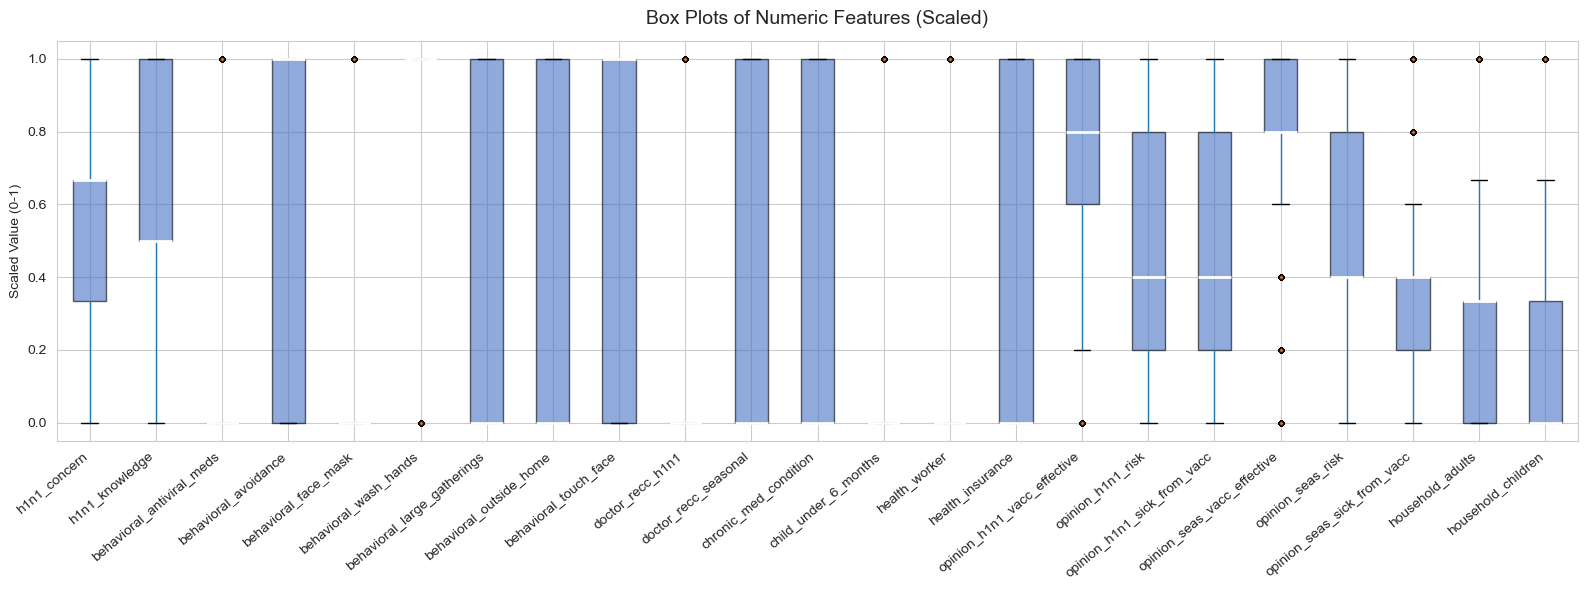

In [ ]:
# Box Plots
# To detect outliers

scaler = MinMaxScaler()
scaled_df = pd.DataFrame(
    scaler.fit_transform(flu_train_merged[numeric_cols].fillna(0)),
    columns = numeric_cols
)

fig, ax = plt.subplots(figsize = (16, 6))
scaled_df.boxplot(
    ax = ax,
    patch_artist = True,
    boxprops = dict(facecolor = '#4472C4', alpha = 0.6),
    medianprops = dict(color = 'white', linewidth = 2),
    flierprops = dict(marker = 'o', markerfacecolor = '#ED7D31', markersize = 3, alpha = 0.5)
)
ax.set_title('Box Plots of Numeric Features (Scaled)', fontsize = 14, pad = 12)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 40, ha = 'right')
ax.set_ylabel('Scaled Value (0-1)')
plt.tight_layout()
plt.savefig('../reports/figures/outliers_01_box_plots.png', dpi =150)
plt.show()



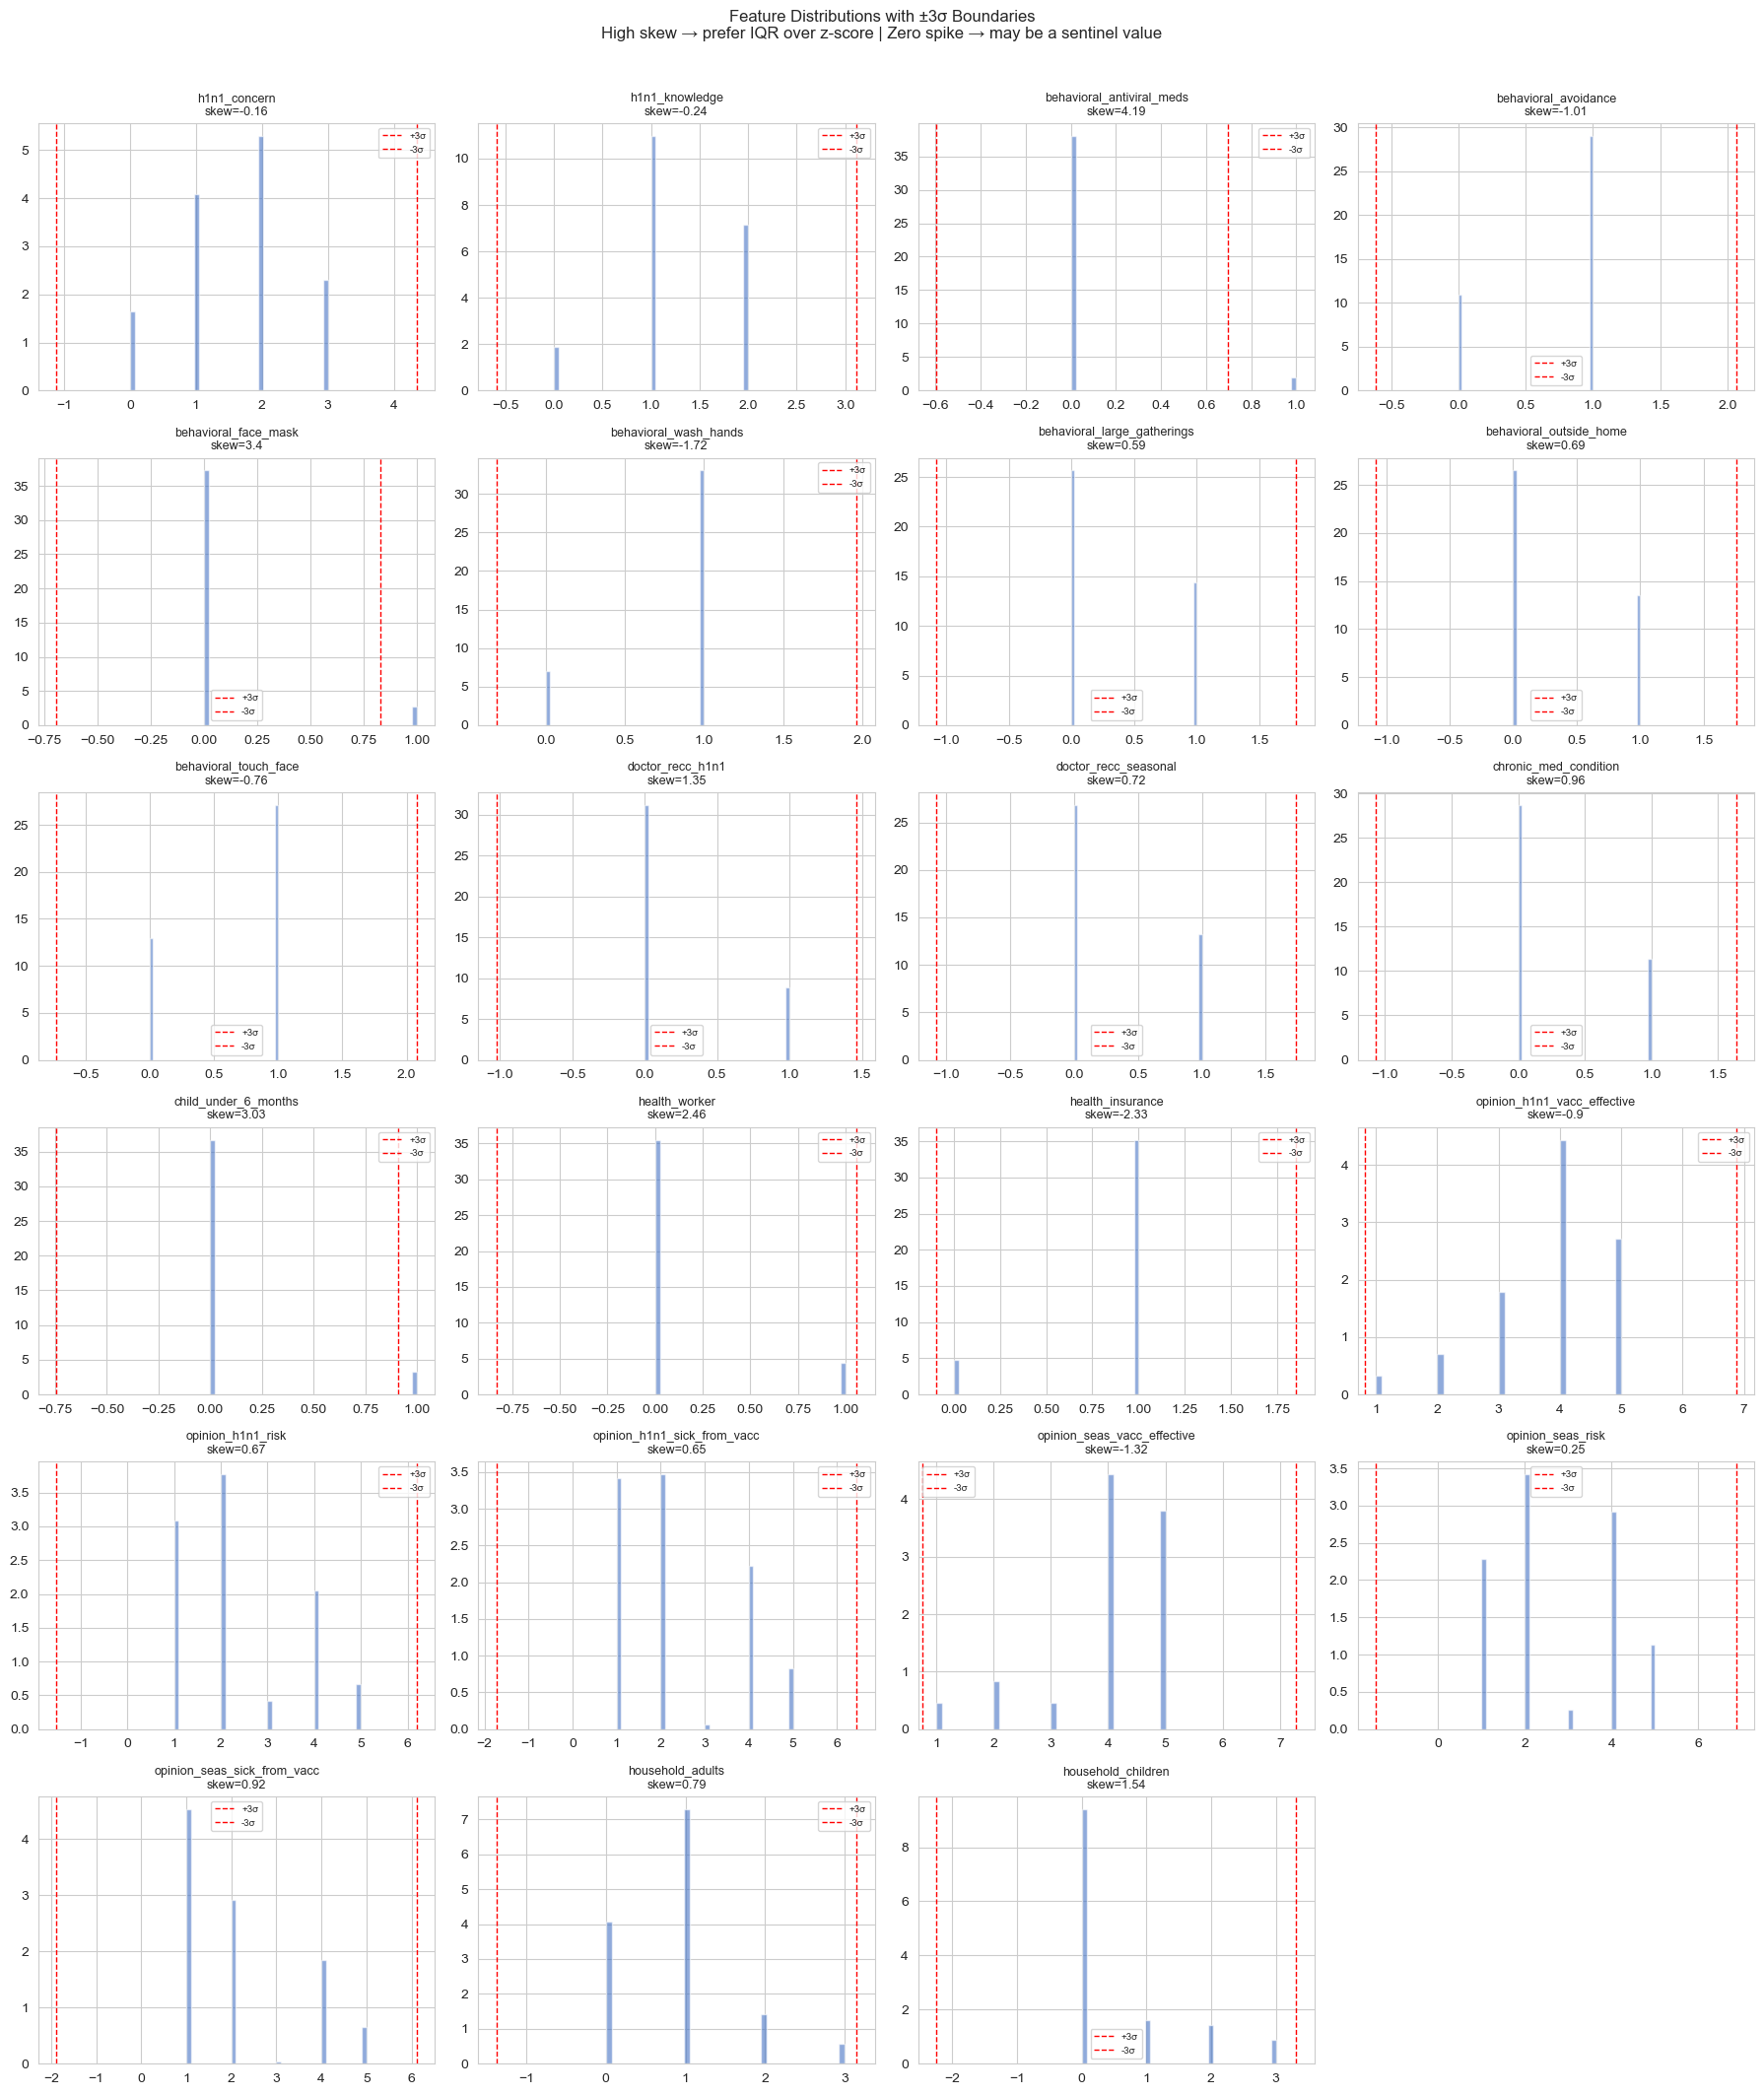

Skewness by feature (|skew| > 1 → prefer IQR over z-score):
                    feature  skewness
  behavioral_antiviral_meds  4.186503
       behavioral_face_mask  3.401744
       child_under_6_months  3.033008
              health_worker  2.462087
         household_children  1.543903
           doctor_recc_h1n1  1.349742
      chronic_med_condition  0.962097
opinion_seas_sick_from_vacc  0.919587
           household_adults  0.786572
       doctor_recc_seasonal  0.724397
    behavioral_outside_home  0.688227
          opinion_h1n1_risk  0.672957
opinion_h1n1_sick_from_vacc  0.651281
behavioral_large_gatherings  0.589522
          opinion_seas_risk  0.250923
               h1n1_concern -0.159913
             h1n1_knowledge -0.239224
      behavioral_touch_face -0.758355
opinion_h1n1_vacc_effective -0.902706
       behavioral_avoidance -1.011306
opinion_seas_vacc_effective -1.315177
      behavioral_wash_hands -1.716380
           health_insurance -2.334909


In [ ]:
# Histogram + KDE

n_rows = (len(numeric_cols) + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax   = axes[i]
    data = flu_train_merged[col].dropna()
    mean, std = data.mean(), data.std()

    ax.hist(data, bins=40, color='#4472C4', alpha=0.6,
            edgecolor='white', density=True)

    if len(data.unique()) > 5:
        data.plot(kind='kde', ax=ax, color='#ED7D31', linewidth=2)

    ax.axvline(mean + 3 * std, color='red', linestyle='--',
               linewidth=1, label='+3σ')
    ax.axvline(mean - 3 * std, color='red', linestyle='--',
               linewidth=1, label='-3σ')

    skewness = round(data.skew(), 2)
    ax.set_title(f'{col}\nskew={skewness}', fontsize=9)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Feature Distributions with ±3σ Boundaries\n'
    'High skew → prefer IQR over z-score | '
    'Zero spike → may be a sentinel value',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('../reports/figures/outlier_02_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# Print skewness to guide which test to use
skew_df = (flu_train_merged[numeric_cols]
           .skew()
           .reset_index()
           .rename(columns={'index': 'feature', 0: 'skewness'})
           .sort_values('skewness', ascending=False))
print("Skewness by feature (|skew| > 1 → prefer IQR over z-score):")
print(skew_df.to_string(index=False))

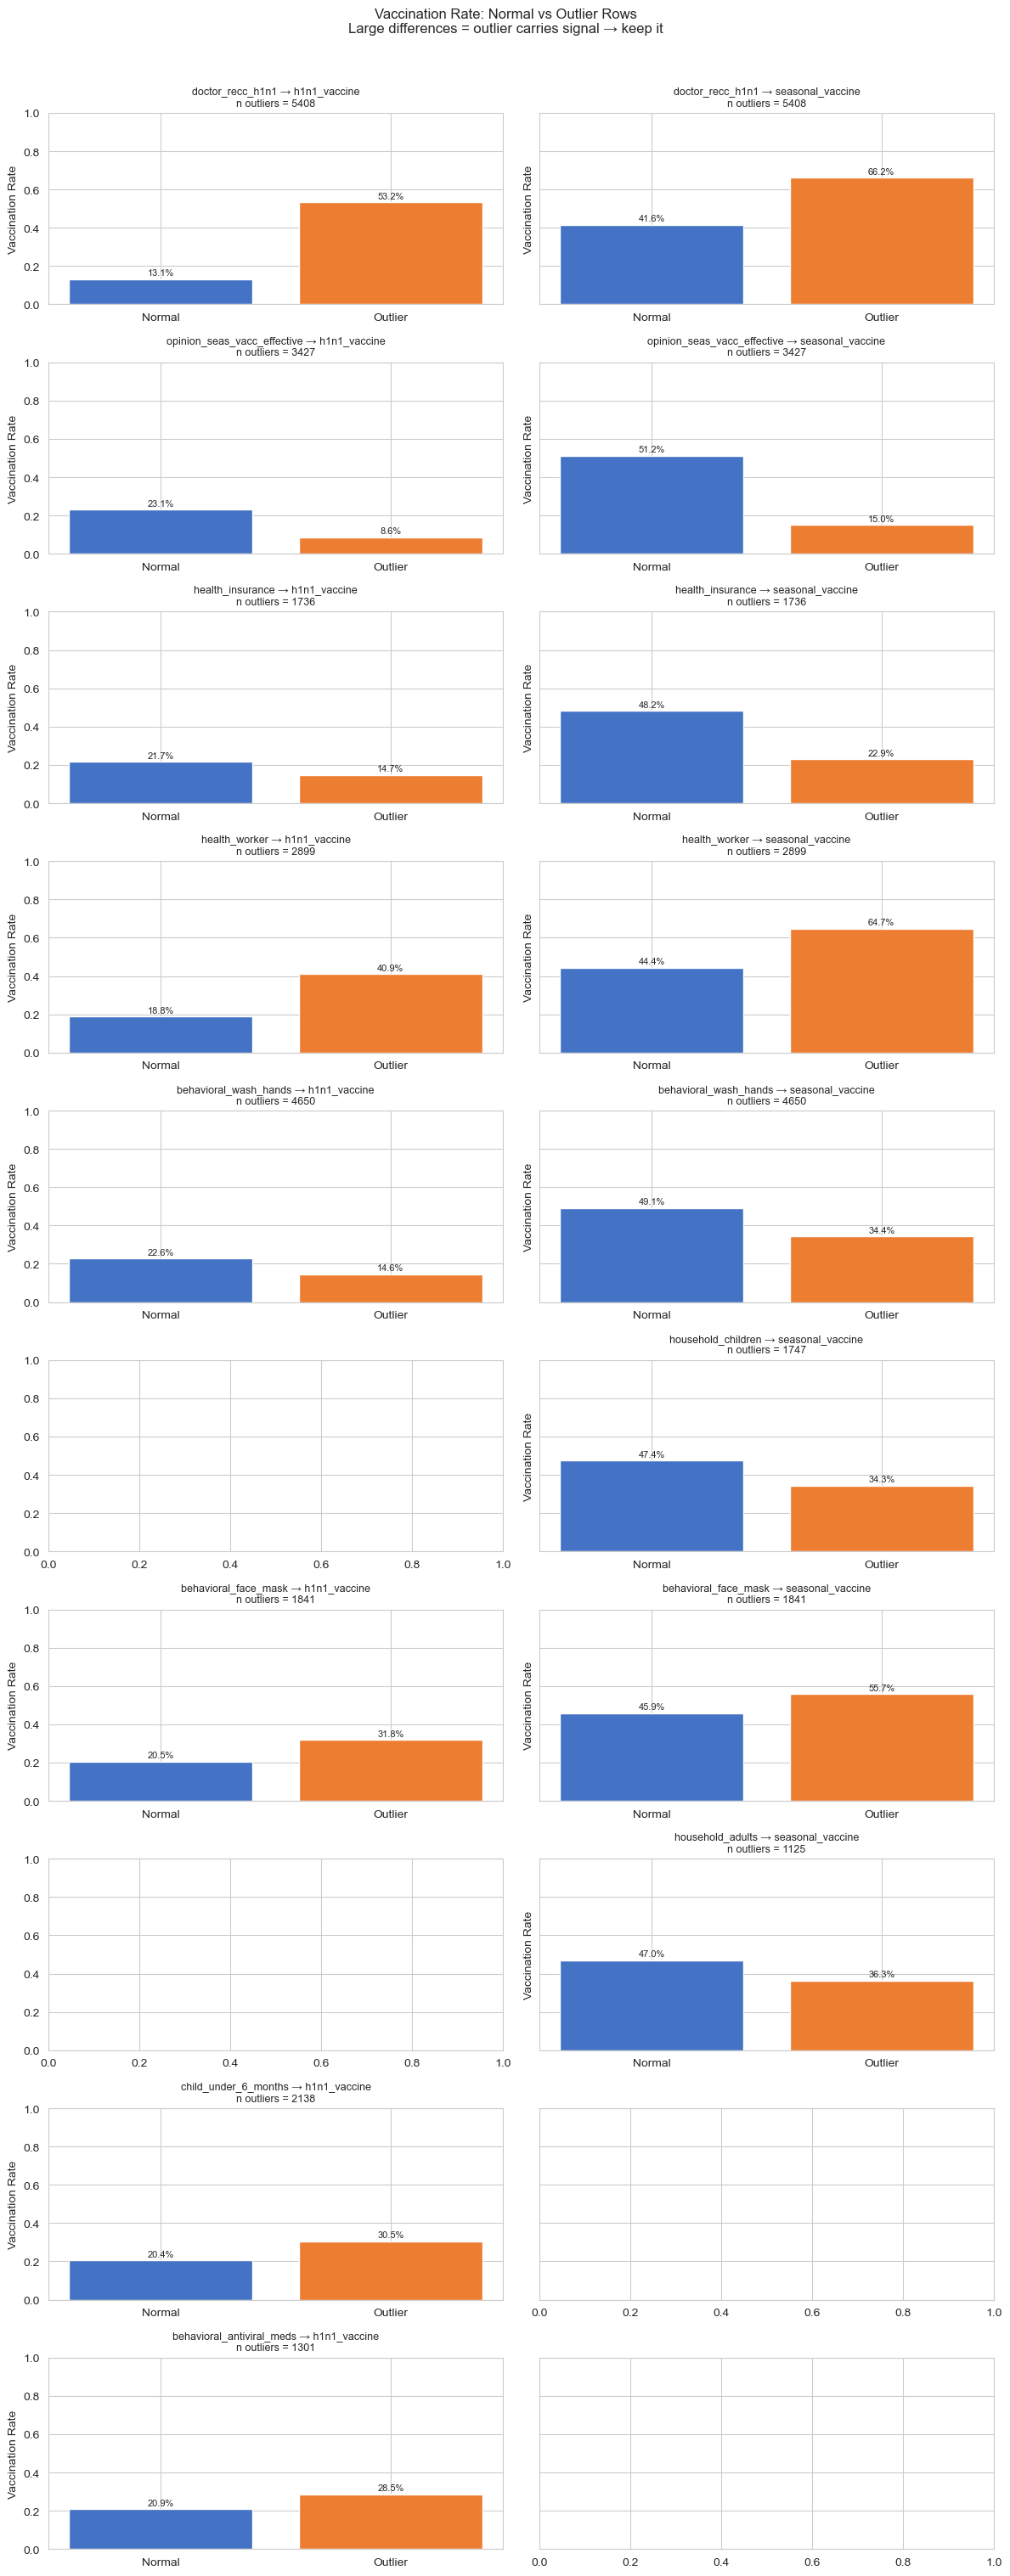

In [ ]:
# Target Rate by Outlier Group
records = []

for col in numeric_cols:
    data    = flu_train_merged[col].dropna()
    q1, q3  = data.quantile(0.25), data.quantile(0.75)
    iqr     = q3 - q1
    lower   = q1 - 1.5 * iqr
    upper   = q3 + 1.5 * iqr

    outlier_mask = (
        (flu_train_merged[col] < lower) |
        (flu_train_merged[col] > upper)
    )

    for target in TARGET_COLS:
        rate_normal  = flu_train_merged.loc[~outlier_mask, target].mean()
        rate_outlier = flu_train_merged.loc[outlier_mask,  target].mean()
        records.append({
            'feature':      col,
            'target':       target,
            'n_outliers':   int(outlier_mask.sum()),
            'rate_normal':  rate_normal,
            'rate_outlier': rate_outlier,
            'difference':   abs(rate_normal - rate_outlier)
        })

rate_df  = pd.DataFrame(records)
plot_df  = rate_df[
    (rate_df['difference'] > 0.05) &
    (rate_df['n_outliers'] >= 10)
].sort_values('difference', ascending=False)

if len(plot_df) == 0:
    print("No meaningful target rate differences found.")
    print("Outliers do not carry strong predictive signal — "
          "safe to cap or remove.")
else:
    n_features = plot_df['feature'].nunique()
    fig, axes  = plt.subplots(n_features, 2,
                               figsize=(12, n_features * 3),
                               sharey=True)
    if n_features == 1:
        axes = np.array([axes])

    for i, feature in enumerate(plot_df['feature'].unique()):
        subset = plot_df[plot_df['feature'] == feature]
        for j, target in enumerate(TARGET_COLS):
            ax  = axes[i, j]
            row = subset[subset['target'] == target]
            if len(row) == 0:
                continue

            bars = ax.bar(
                ['Normal', 'Outlier'],
                [row['rate_normal'].values[0],
                 row['rate_outlier'].values[0]],
                color=['#4472C4', '#ED7D31'],
                edgecolor='white'
            )
            ax.set_title(
                f'{feature} → {target}\n'
                f"n outliers = {int(row['n_outliers'].values[0])}",
                fontsize=9
            )
            ax.set_ylim(0, 1)
            ax.set_ylabel('Vaccination Rate')

            for bar in bars:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f'{bar.get_height():.1%}',
                    ha='center', fontsize=8
                )

    plt.suptitle(
        'Vaccination Rate: Normal vs Outlier Rows\n'
        'Large differences = outlier carries signal → keep it',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.savefig('../reports/figures/outlier_03_target_rate.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Z-Score
z_results = []

for col in numeric_cols:
    data       = flu_train_merged[col].dropna()
    z_scores   = np.abs(stats.zscore(data))
    n_outliers = int((z_scores > 3).sum())

    z_results.append({
        'feature':      col,
        'n_outliers':   n_outliers,
        'pct_outliers': round(n_outliers / len(data), 4),
        'max_z':        round(float(z_scores.max()), 2),
        'flagged':      n_outliers > 0
    })

z_df = (pd.DataFrame(z_results)
        .sort_values('n_outliers', ascending=False))

print("=" * 50)
print("Z-Score Test  (threshold: |z| > 3)")
print("=" * 50)
flagged = z_df[z_df['flagged']]
if len(flagged) == 0:
    print("No z-score outliers detected.")
else:
    print(flagged.to_string(index=False))
print(f"\nClean columns: {(~z_df['flagged']).sum()} / {len(z_df)}")

Z-Score Test  (threshold: |z| > 3)
                  feature  n_outliers  pct_outliers  max_z  flagged
     child_under_6_months        2138        0.0826   3.33     True
     behavioral_face_mask        1841        0.0690   3.67     True
behavioral_antiviral_meds        1301        0.0488   4.41     True

Clean columns: 20 / 23


In [ ]:
# IQR Forest
iqr_results = []

for col in numeric_cols:
    data        = flu_train_merged[col].dropna()
    q1, q3      = data.quantile(0.25), data.quantile(0.75)
    iqr         = q3 - q1
    lower       = q1 - 1.5 * iqr
    upper       = q3 + 1.5 * iqr
    n_low       = int((data < lower).sum())
    n_high      = int((data > upper).sum())
    n_total     = n_low + n_high

    iqr_results.append({
        'feature':        col,
        'lower_fence':    round(lower, 3),
        'upper_fence':    round(upper, 3),
        'n_below':        n_low,
        'n_above':        n_high,
        'n_total':        n_total,
        'pct_outliers':   round(n_total / len(data), 4),
        'flagged':        n_total > 0
    })

iqr_df = (pd.DataFrame(iqr_results)
          .sort_values('n_total', ascending=False))

print("=" * 60)
print("IQR Test  (threshold: 1.5 × IQR beyond Q1/Q3)")
print("=" * 60)
flagged_iqr = iqr_df[iqr_df['flagged']]
if len(flagged_iqr) == 0:
    print("No IQR outliers detected.")
else:
    print(flagged_iqr[['feature', 'lower_fence', 'upper_fence',
                         'n_below', 'n_above',
                         'n_total', 'pct_outliers']]
          .to_string(index=False))
print(f"\nClean columns: {(~iqr_df['flagged']).sum()} / {len(iqr_df)}")

IQR Test  (threshold: 1.5 × IQR beyond Q1/Q3)
                    feature  lower_fence  upper_fence  n_below  n_above  n_total  pct_outliers
           doctor_recc_h1n1          0.0          0.0        0     5408     5408        0.2203
      behavioral_wash_hands          1.0          1.0     4650        0     4650        0.1744
opinion_seas_vacc_effective          2.5          6.5     3427        0     3427        0.1306
              health_worker          0.0          0.0        0     2899     2899        0.1119
       child_under_6_months          0.0          0.0        0     2138     2138        0.0826
       behavioral_face_mask          0.0          0.0        0     1841     1841        0.0690
         household_children         -1.5          2.5        0     1747     1747        0.0660
           health_insurance          1.0          1.0     1736        0     1736        0.1203
  behavioral_antiviral_meds          0.0          0.0        0     1301     1301        0.0488
    

In [ ]:
# Isolation Test
X_iso = flu_train_merged[numeric_cols].fillna(
    flu_train_merged[numeric_cols].median()
)

iso = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    random_state=42
)
labels = iso.fit_predict(X_iso)
scores = iso.score_samples(X_iso)

n_flagged = (labels == -1).sum()

print("=" * 55)
print("Isolation Forest — Multivariate Outlier Detection")
print("=" * 55)
print(f"Total rows:     {len(flu_train_merged)}")
print(f"Flagged:        {n_flagged} ({n_flagged/len(flu_train_merged):.1%})")

# Check whether multivariate outliers differ on the target
iso_mask = labels == -1
print("\nVaccination rates — normal vs multivariate outlier rows:")
for target in TARGET_COLS:
    rate_normal  = flu_train_merged.loc[~iso_mask, target].mean()
    rate_outlier = flu_train_merged.loc[iso_mask,  target].mean()
    diff         = abs(rate_normal - rate_outlier)
    signal       = "signal present" if diff > 0.05 else "no strong signal"
    print(f"  {target}: normal={rate_normal:.3f}, "
          f"outlier={rate_outlier:.3f}, "
          f"diff={diff:.3f} ({signal})")

Isolation Forest — Multivariate Outlier Detection
Total rows:     26707
Flagged:        1336 (5.0%)

Vaccination rates — normal vs multivariate outlier rows:
  h1n1_vaccine: normal=0.206, outlier=0.344, diff=0.138 (signal present)
  seasonal_vaccine: normal=0.466, outlier=0.457, diff=0.009 (no strong signal)


In [ ]:
# Summary Tables
summary = []

for col in numeric_cols:
    z_row   = z_df[z_df['feature'] == col].iloc[0]
    iqr_row = iqr_df[iqr_df['feature'] == col].iloc[0]

    tr_col   = rate_df[rate_df['feature'] == col]
    max_diff = tr_col['difference'].max() if len(tr_col) > 0 else 0

    n_z     = int(z_row['n_outliers'])
    n_iqr   = int(iqr_row['n_total'])
    pct_iqr = iqr_row['pct_outliers']

    skew_val = abs(flu_train_merged[col].skew())
    test_to_trust = 'IQR' if skew_val > 1 else 'Z-score'

    # Severity
    if pct_iqr > 0.10:
        severity = 'High'
    elif n_iqr > 0 or n_z > 0:
        severity = 'Moderate'
    else:
        severity = 'None'

    # Action
    if severity == 'None':
        action = 'No action needed'
    elif max_diff > 0.05:
        action = 'Keep — carries predictive signal'
    elif pct_iqr > 0.10:
        action = 'Investigate — unusually high outlier rate'
    else:
        action = 'Winsorize or log-transform'

    summary.append({
        'feature':        col,
        'n_zscore':       n_z,
        'n_iqr':          n_iqr,
        'pct_iqr':        f'{pct_iqr:.1%}',
        'target_diff':    f'{max_diff:.3f}',
        'trust':          test_to_trust,
        'severity':       severity,
        'action':         action
    })

summary_df = (pd.DataFrame(summary)
              .sort_values('n_iqr', ascending=False))

print("=" * 70)
print("OUTLIER ANALYSIS SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))

OUTLIER ANALYSIS SUMMARY
                    feature  n_zscore  n_iqr pct_iqr target_diff   trust severity                           action
           doctor_recc_h1n1         0   5408   22.0%       0.401     IQR     High Keep — carries predictive signal
      behavioral_wash_hands         0   4650   17.4%       0.148     IQR     High Keep — carries predictive signal
opinion_seas_vacc_effective         0   3427   13.1%       0.362     IQR     High Keep — carries predictive signal
              health_worker         0   2899   11.2%       0.221     IQR     High Keep — carries predictive signal
       child_under_6_months      2138   2138    8.3%       0.101     IQR Moderate Keep — carries predictive signal
       behavioral_face_mask      1841   1841    6.9%       0.114     IQR Moderate Keep — carries predictive signal
         household_children         0   1747    6.6%       0.131     IQR Moderate Keep — carries predictive signal
           health_insurance         0   1736   12.0%   

In [ ]:
# Winsorize or log-transform features that have outliers but do not carry strong predictive signal (target_diff ≤ 0.05)
for col in summary_df[summary_df['action'] == 'Winsorize or log-transform']['feature']:
    flu_train_merged[col] = winsorize(
        flu_train_merged[col].fillna(flu_train_merged[col].median()),
        limits=[0.01, 0.01]
    )
    print(f"Winsorized: {col}")

In [ ]:
# Summary statistics
# TODO: Display descriptive statistics

## 9. Cardinality Check

**Goal:** Know how many unique values each categorical column has so we can choose the right encoding strategy
- For every categorical column, compute the number of unique values and % of total rows
- Identify constant columns (1 unique value) and flag to drop
- Identify near-ID columns (almost as many unique values as rows) and flag to drop
- Classify each column by encoding strategy


|**Unique values** | **Encoding Strategy** |
|------------------|-----------------------|
| 1                | Drop - no information |
| 2                | Label encode          |
| 3 - 15           | Label encode or one-hot encode |
| 16 - 100         | Frequency encode      |
| 100+             | Frequency encode or target encode |
| ~n rows          | Drop - effectively an ID |

In [ ]:
# Cardinality Check (Categorical Columns)

cardinality = pd.DataFrame({
    'n_unique':     [flu_train_merged[c].nunique() for c in categorical_cols],
    'pct_unique':   [flu_train_merged[c].nunique() / len(flu_train_merged) for c in categorical_cols],
    'top_value':    [flu_train_merged[c].value_counts().index[0] for c in categorical_cols],
    'top_pct':      [flu_train_merged[c].value_counts(normalize=True).iloc[0] for c in categorical_cols]
}, index=categorical_cols).sort_values('n_unique', ascending=False)

print("=" * 60)
print("Categorical Feature Cardinality")
print("=" * 60)
print(cardinality.round(3))

Categorical Feature Cardinality
                       n_unique  pct_unique                  top_value  \
employment_occupation        23       0.001                   xtkaffoo   
employment_industry          21       0.001                   fcxhlnwr   
hhs_geo_region               10       0.000                   lzgpxyit   
age_group                     5       0.000                  65+ Years   
education                     4       0.000           College Graduate   
race                          4       0.000                      White   
income_poverty                3       0.000  <= $75,000, Above Poverty   
employment_status             3       0.000                   Employed   
census_msa                    3       0.000   MSA, Not Principle  City   
sex                           2       0.000                     Female   
marital_status                2       0.000                    Married   
rent_or_own                   2       0.000                        Own   

     

## 10. Redundant and Near-Duplicate Column Check

**Goal:** Identify columns that carry identical or near identical information so only one is kept.

In [ ]:
# Redundant and near-duplicate column check

# Columns with identical values
def find_duplicate_columns(df):
    duplicates = []
    cols = df.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if df[cols[i]].equals(df[cols[j]]):
                duplicates.append((cols[i], cols[j]))
    return duplicates

duplicate_cols = find_duplicate_columns(flu_train_merged.drop(columns = TARGET_COLS))
print(f"Identical column pairs: {duplicate_cols}")

# Highly correlated numeric columns (near-duplicates)
corr_matrix = flu_train_merged[numeric_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper_tri.stack().reset_index().rename(columns={'level_0': 'col_1', 'level_1': 'col_2', 0: 'correlation'})
high_corr_pairs = high_corr_pairs.query('correlation > 0.95').sort_values('correlation', ascending=False)

print(f"\nHighly correlated column pairs (correlation > 0.95): ")
print(high_corr_pairs.to_string(index=False))

Identical column pairs: []

Highly correlated column pairs (correlation > 0.95): 
Empty DataFrame
Columns: [col_1, col_2, correlation]
Index: []


## 11. Feature-Target Relationships

**Goal:** Identify which features are most predictive before modeling so feature engineering is guided by evidence
- Compute correlation of each numeric feature with each target. Print the top 10
- For low-cardinality categorical columns, plot target column (e.g.vaccination rate) by category value
- Identify the top 5 strongest predictors for each target
- Identify features with little or no relationship to the target (candidates to de-prioritize)
- Write down: which features should feature engineering focus on?


Correlation of numeric features with target: h1n1_vaccine
doctor_recc_h1n1               0.394
opinion_h1n1_risk              0.323
opinion_h1n1_vacc_effective    0.269
opinion_seas_risk              0.259
doctor_recc_seasonal           0.210
opinion_seas_vacc_effective    0.179
health_worker                  0.170
h1n1_concern                   0.122
health_insurance               0.121
h1n1_knowledge                 0.118
Name: h1n1_vaccine, dtype: float64

Correlation of numeric features with target: seasonal_vaccine
opinion_seas_risk              0.390
doctor_recc_seasonal           0.369
opinion_seas_vacc_effective    0.362
opinion_h1n1_risk              0.217
opinion_h1n1_vacc_effective    0.205
health_insurance               0.201
doctor_recc_h1n1               0.199
chronic_med_condition          0.170
h1n1_concern                   0.155
health_worker                  0.127
Name: seasonal_vaccine, dtype: float64


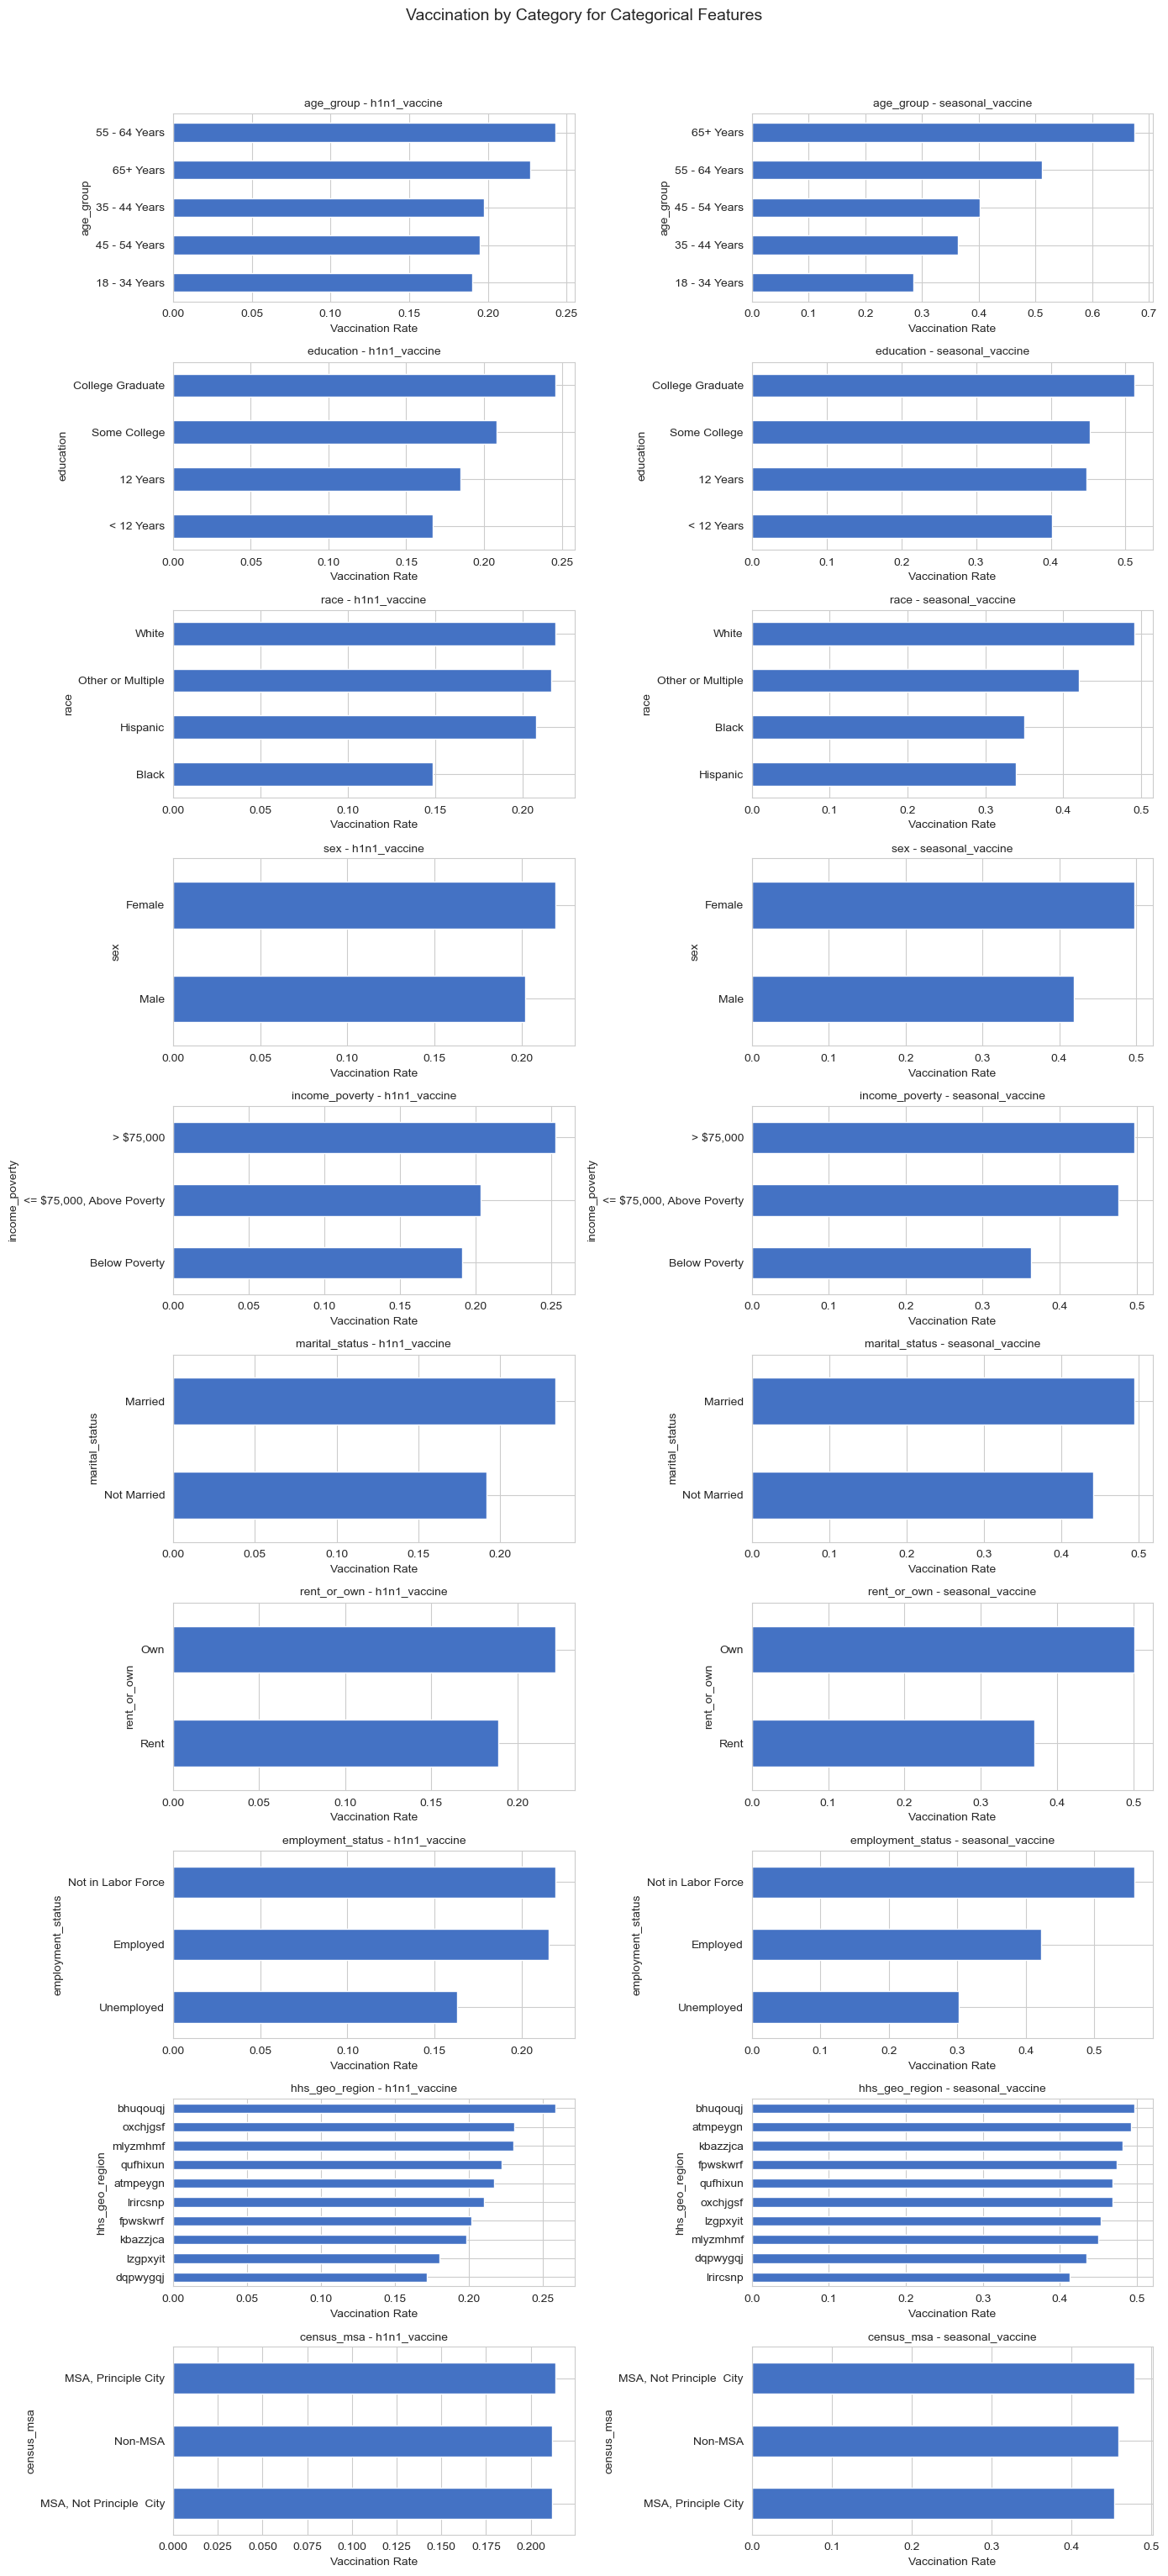

In [ ]:
# Feature-Target Relationships

# Numeric features: correlation with each target
for target in TARGET_COLS:
    corr = (flu_train_merged[numeric_cols + [target]]
            .corr()[target]
            .drop(target)
            .sort_values(key=abs, ascending=False))

    print(f"\nCorrelation of numeric features with target: {target}")
    print(corr.head(10).round(3))

# Categorical features: vaccination rate by category
cat_cols_clean = [c for c in categorical_cols if flu_train_merged[c].nunique() <= 15]

fig, axes = plt.subplots(
    len(cat_cols_clean), len(TARGET_COLS),
    figsize=(14, len(cat_cols_clean) * 3)
)

for i, col in enumerate(cat_cols_clean):
    for j, target in enumerate(TARGET_COLS):
        ax = axes[i, j] if len(cat_cols_clean) > 1 else axes[j]
        rate = flu_train_merged.groupby(col)[target].mean().sort_values()
        rate.plot(kind='barh', ax=ax, color='#4472C4', edgecolor='white')
        ax.set_title(f'{col} - {target}', fontsize=10)
        ax.set_xlabel('Vaccination Rate')

plt.suptitle('Vaccination by Category for Categorical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/feature_target_relationships_01_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Class Imbalance Quantification

**Goal:** Formally measure imbalance so the model configuration decision is evidence-based


In [ ]:
# Class Imbalance Quantification

from sklearn.utils.class_weight import compute_class_weight

for target in TARGET_COLS:
    classes = flu_train_merged[target].dropna().unique()
    weights = compute_class_weight(
        class_weight = 'balanced',
        classes = np.sort(classes),
        y = flu_train_merged[target].dropna()
    )

    imbalance_ratio = flu_train_merged[target].value_counts().iloc[0] / flu_train_merged[target].value_counts().iloc[-1]

print(f"\n{target}:")
print(f"  Class counts:     {dict(flu_train_merged[target].value_counts())}")
print(f"  Imbalance ratio:  {imbalance_ratio:.2f}:1")
print(f"  Balanced weights: {dict(zip(np.sort(classes), weights.round(3)))}")
print(f"  Recommendation:   ", end='')

if imbalance_ratio > 10:
    print("Severe. Use SMOTE or class weights, "
          "report F1-score, not accuracy.")
elif imbalance_ratio > 3:
    print("Moderate. Use class_weight='balanced' in model")
else:
    print("Mild. Standard training is fine. Monitor recall") 


seasonal_vaccine:
  Class counts:     {0: np.int64(14272), 1: np.int64(12435)}
  Imbalance ratio:  1.15:1
  Balanced weights: {np.int64(0): np.float64(0.936), np.int64(1): np.float64(1.074)}
  Recommendation:   Mild. Standard training is fine. Monitor recall


## 13. Data Type Validation

**Goal:** Confirm every column is stored as the correct type


In [ ]:
# Data type validation

type_issues = []

for col in flu_train_merged.columns:
    if col in TARGET_COLS:
        continue

    sample = flu_train_merged[col].dropna().head(100)

    # Numeric stored as object
    if flu_train_merged[col].dtype == 'object':
        try:
            pd.to_numeric(sample)
            type_issues.append({
                'column': col,
                'current': 'object',
                'should_be': 'numeric',
                'action': 'pd.to_numeric()'
            })
        except (ValueError, TypeError):
            pass

    # Date stored as object
    if flu_train_merged[col].dtype == 'object':
        if any(keyword in col.lower() for keyword in ['date', 'time', 'year', 'month']):
            type_issues.append({
                'column': col,
                'current': 'object',
                'should_be': 'datetime',
                'action': 'pd.to_datetime()'
            })


if type_issues:
    print("\nData type issues detected:")
    print(pd.DataFrame(type_issues).to_string(index=False))
else:
    print("\nNo data type issues detected. All columns have appropriate types.")



No data type issues detected. All columns have appropriate types.


## 9. Key Findings & Insights

### Summary of Findings:
1. **Data Quality**: 
   - TODO: Document missing data patterns
   - TODO: Note any data quality issues

2. **Target Variable**:
   - TODO: Describe distribution characteristics
   - TODO: Note city differences

3. **Temporal Patterns**:
   - TODO: Describe seasonality
   - TODO: Note trends over time

4. **Feature Relationships**:
   - TODO: List most important features
   - TODO: Note interesting correlations

### Implications for Modeling:
- TODO: What preprocessing is needed?
- TODO: What features should be engineered?
- TODO: Should cities be modeled separately?
- TODO: What model types might work well?

## 10. Next Steps

Based on this EDA:
1. TODO: Data cleaning priorities
2. TODO: Feature engineering ideas
3. TODO: Modeling approach considerations